# 导数、偏导、梯度 - 可视化

本 Notebook 生成三张图：
1. 一元函数导数（曲线 + 切线）
2. 二元函数等高线 + 梯度方向
3. 损失曲面 + 梯度下降轨迹

生成的图片会保存到当前目录下的 `assets/`。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assets_dir = Path.cwd() / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)
assets_dir

WindowsPath('D:/BBFEC-FRONT/RL-AND-RL/01_数学基础/01_微积分/assets')

## 图1：一元函数导数（曲线 + 切线）

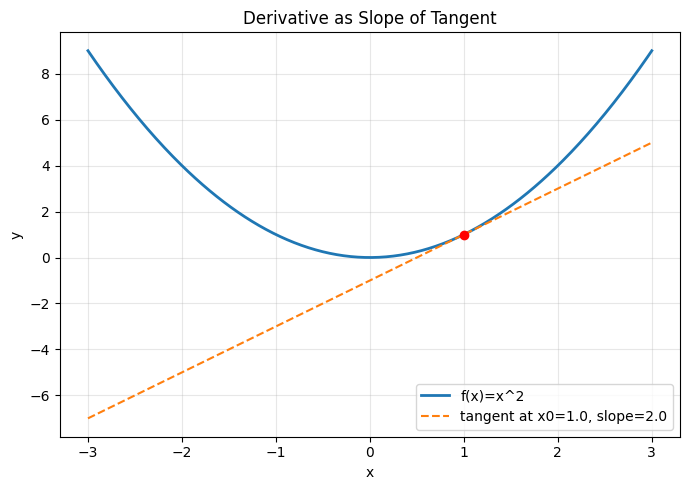

In [2]:
# 例子函数: f(x)=x^2
f = lambda x: x**2
df = lambda x: 2*x

x = np.linspace(-3, 3, 400)
x0 = 1.0
y0 = f(x0)
k = df(x0)
tangent = y0 + k * (x - x0)

plt.figure(figsize=(7, 5))
plt.plot(x, f(x), label='f(x)=x^2', linewidth=2)
plt.plot(x, tangent, '--', label=f'tangent at x0={x0}, slope={k:.1f}')
plt.scatter([x0], [y0], c='red', zorder=5)
plt.title('Derivative as Slope of Tangent')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(assets_dir / '01_derivative_tangent.png', dpi=160)
plt.show()

## 图2：二元函数等高线 + 梯度方向

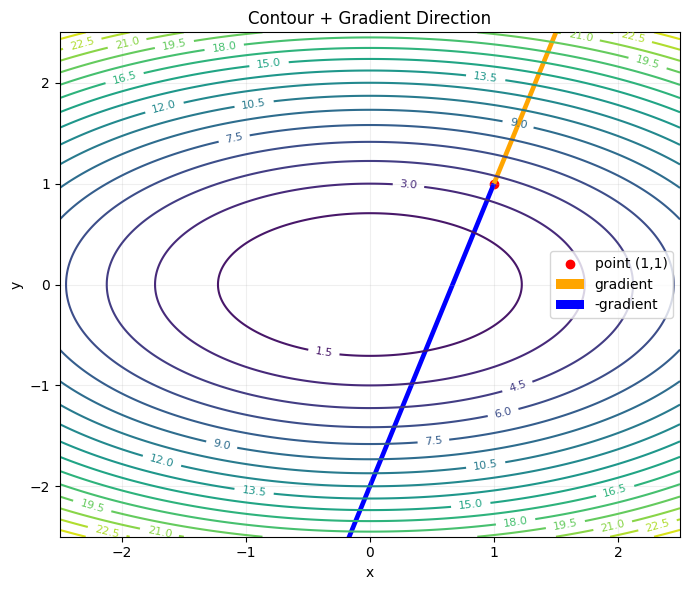

In [3]:
# 例子函数: f(x,y)=x^2+3y^2
def f2(x, y):
    return x**2 + 3*y**2

def grad_f2(x, y):
    return np.array([2*x, 6*y])

xx = np.linspace(-2.5, 2.5, 250)
yy = np.linspace(-2.5, 2.5, 250)
X, Y = np.meshgrid(xx, yy)
Z = f2(X, Y)

p = np.array([1.0, 1.0])
g = grad_f2(p[0], p[1])
ng = -g

plt.figure(figsize=(7, 6))
contours = plt.contour(X, Y, Z, levels=20)
plt.clabel(contours, inline=True, fontsize=8)
plt.scatter([p[0]], [p[1]], c='red', label='point (1,1)')
plt.quiver(p[0], p[1], g[0], g[1], angles='xy', scale_units='xy', scale=1, color='orange', label='gradient')
plt.quiver(p[0], p[1], ng[0], ng[1], angles='xy', scale_units='xy', scale=1, color='blue', label='-gradient')
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.title('Contour + Gradient Direction')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(assets_dir / '02_contour_gradient.png', dpi=160)
plt.show()

## 图3：损失曲面 + 梯度下降轨迹

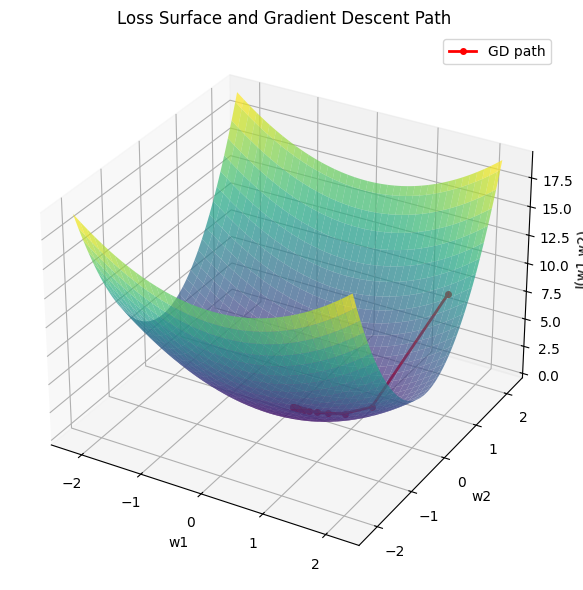

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# 梯度下降轨迹
lr = 0.15
steps = 12
w = np.array([1.8, 1.4], dtype=float)
path = [w.copy()]

for _ in range(steps):
    w = w - lr * grad_f2(w[0], w[1])
    path.append(w.copy())

path = np.array(path)
Z_path = f2(path[:, 0], path[:, 1])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 为了清晰，画稍稀疏的网格
xx3 = np.linspace(-2.2, 2.2, 80)
yy3 = np.linspace(-2.2, 2.2, 80)
X3, Y3 = np.meshgrid(xx3, yy3)
Z3 = f2(X3, Y3)

ax.plot_surface(X3, Y3, Z3, cmap='viridis', alpha=0.7, linewidth=0)
ax.plot(path[:, 0], path[:, 1], Z_path, 'r.-', linewidth=2, markersize=8, label='GD path')

ax.set_title('Loss Surface and Gradient Descent Path')
ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('J(w1,w2)')
ax.legend()
plt.tight_layout()
plt.savefig(assets_dir / '03_loss_surface_path.png', dpi=160)
plt.show()

### 输出文件
- `assets/01_derivative_tangent.png`
- `assets/02_contour_gradient.png`
- `assets/03_loss_surface_path.png`